In [1]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

import os

In [2]:
Dir_working = '/work/desai-lab/xuanyang/Project/Semantic/analysis/ParametricModulation/Nastase/allstories/FactorAnalysis/models'
model = 'Nvar113NFA8_LPAC_multipleReg'
mask = 'threshold_SVC3_LR'
threshold = 'bisidedNN2_1tailp005'
Dir_figure = os.path.join(Dir_working,model,'figures_SVC',mask,threshold,'palette2')

In [3]:
def cropfigure(path_input,path_output,List_coordinates):
    image = Image.open(path_input)
    img_array = np.array(image)
    for coordinates in List_coordinates:
        x_start,y_start,x_end,y_end = coordinates
        img_array[y_start:y_end, x_start:x_end] = [255, 255, 255]  # RGB white
        # img_array[y_start:y_end, x_start:x_end] = [0, 0, 0]  # RGB black
    modified_image = Image.fromarray(img_array)
    modified_image.save(path_output)
    

### Remove colorbar and labels

In [5]:
List_files =[f"FA{x}_bisidedNN2_1tailp005_U12.jpg" for x in range(1,9)]
img_w,img_h = [2000,1500]
center_h = 750
center_w = 1000
# Extract colorbar
path_colorbar = os.path.join(Dir_figure,'colorbar_raw.jpg')
if not os.path.exists(path_colorbar):
    image = Image.open(os.path.join(Dir_figure,List_files[0]))
    y_start, x_start = center_h-198, center_w-201
    y_end, x_end = center_h-150, center_w+200
    img_array = np.array(image)
    modified_image = Image.fromarray(img_array[y_start:y_end, x_start:x_end] )
    path_output = os.path.join(Dir_figure,'colorbar_raw.jpg')
    modified_image.save(path_output)

# Figure
coordinates = [[0,0,200,100],[img_w-200,0,img_w,100],[720, 480, 1280, 650]]
for file in List_files:
    path_input = os.path.join(Dir_figure,file)
    path_output = os.path.join(Dir_figure,file.replace('.jpg','_edit.jpg'))
    cropfigure(path_input,path_output,coordinates)

In [95]:
path_colorbar = os.path.join(Dir_figure,'colorbar_raw.jpg')
image = Image.open(path_colorbar)
img_array = np.array(image)

t_w, t_h = 8,2
# Left
border = img_array[:, :2, :] # get black border
img_tmp = img_array[:,2:199,:]
# stretch
image_pil = Image.fromarray(img_tmp)
h, w = img_tmp.shape[:2]
stretched_image_pil = image_pil.resize((w * t_w, h*t_h), Image.BILINEAR)
stretched_image_np = np.array(stretched_image_pil)

# stretch border as well
image_pil = Image.fromarray(border)
h, w = border.shape[:2]
stretched_image_pil = image_pil.resize((w, h*t_h), Image.BILINEAR)
stretched_border = np.array(stretched_image_pil)


image_left = np.concatenate((stretched_border,stretched_image_np, stretched_border), axis=1)  

# Right

# border = img_array[:, :2, :] # get black border
img_tmp = img_array[:,202:399,:]

# stretch
image_pil = Image.fromarray(img_tmp)
h, w = img_tmp.shape[:2]
stretched_image_pil = image_pil.resize((w * t_w, h*t_h), Image.BILINEAR)


stretched_image_np = np.array(stretched_image_pil)
image_right = np.concatenate((stretched_border,stretched_image_np, stretched_border), axis=1)  

image_left = np.fliplr(image_left)
image_output = np.concatenate((image_left,image_right), axis=0)  

path_output = os.path.join(Dir_figure,'colorbar_layout1.png')
modified_image = Image.fromarray(image_output)
# modified_image.save(path_output)

modified_image.save(path_output, dpi=(300, 300))

### Combine figures into a big one

In [4]:
import matplotlib.font_manager as fm

# Path to your Arial font file (for example on Linux)
font_path = '/work/xy6/dependencies/fonts/arial.ttf'
prop = fm.FontProperties(fname=font_path)

# Labels for each subplot
labels = ["FA1: Frequency", "FA2: PONeighborhood/Length", "FA3: Feedback Consistency", "FA4: Feedforward Consistency", 
          "FA5: Graphotactic/Phonotactic Probability", "FA6: Concreteness", "FA7: Taxonomic Semantic Neighborhood", "FA8: Associative Semantic Neighborhood"]
annotations = [['High','Low'],['Long','Short'],['Consistent','Inconsistent'],['Consistent','Inconsistent'],
               ['High','Low'],['Concrete','Abstract'],['Dense','Sparse'],['Dense','Sparse']]

# Create a 4x2 subplot grid
fig, axes = plt.subplots(4, 2, figsize=(10, 15),dpi=300) 
axes = axes.ravel()  # Flatten the 2D array of axes to 1D for easier indexing

for i, ax in enumerate(axes):
    img_path = os.path.join(Dir_figure,f"FA{i+1}_bisidedNN2_1tailp005_U12_edit.jpg")
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off') 
    ax.set_title(labels[i], fontsize=10, fontproperties=prop)  
    label1,label2 = annotations[i]
    if not divmod(i,2)[1]:
        ax.text(-.05, 0.55, label1, 
            transform=ax.transAxes,  
            fontsize=10, color='red', 
            ha='center', va='center')  
        ax.text(-.05, 0.45, label2, 
            transform=ax.transAxes, 
            fontsize=10, color='blue', 
            ha='center', va='center') 
    else:
        ax.text(1.05, 0.55, label1, 
            transform=ax.transAxes, 
            fontsize=10, color='red', 
            ha='center', va='center') 
        ax.text(1.05, 0.45, label2, 
            transform=ax.transAxes, 
            fontsize=10, color='blue', 
            ha='center', va='center') 

plt.tight_layout()  
plt.close()
filename = os.path.join(Dir_figure,'figure_8in1_layout4.jpg')
fig.savefig(filename,bbox_inches='tight', pad_inches=0)

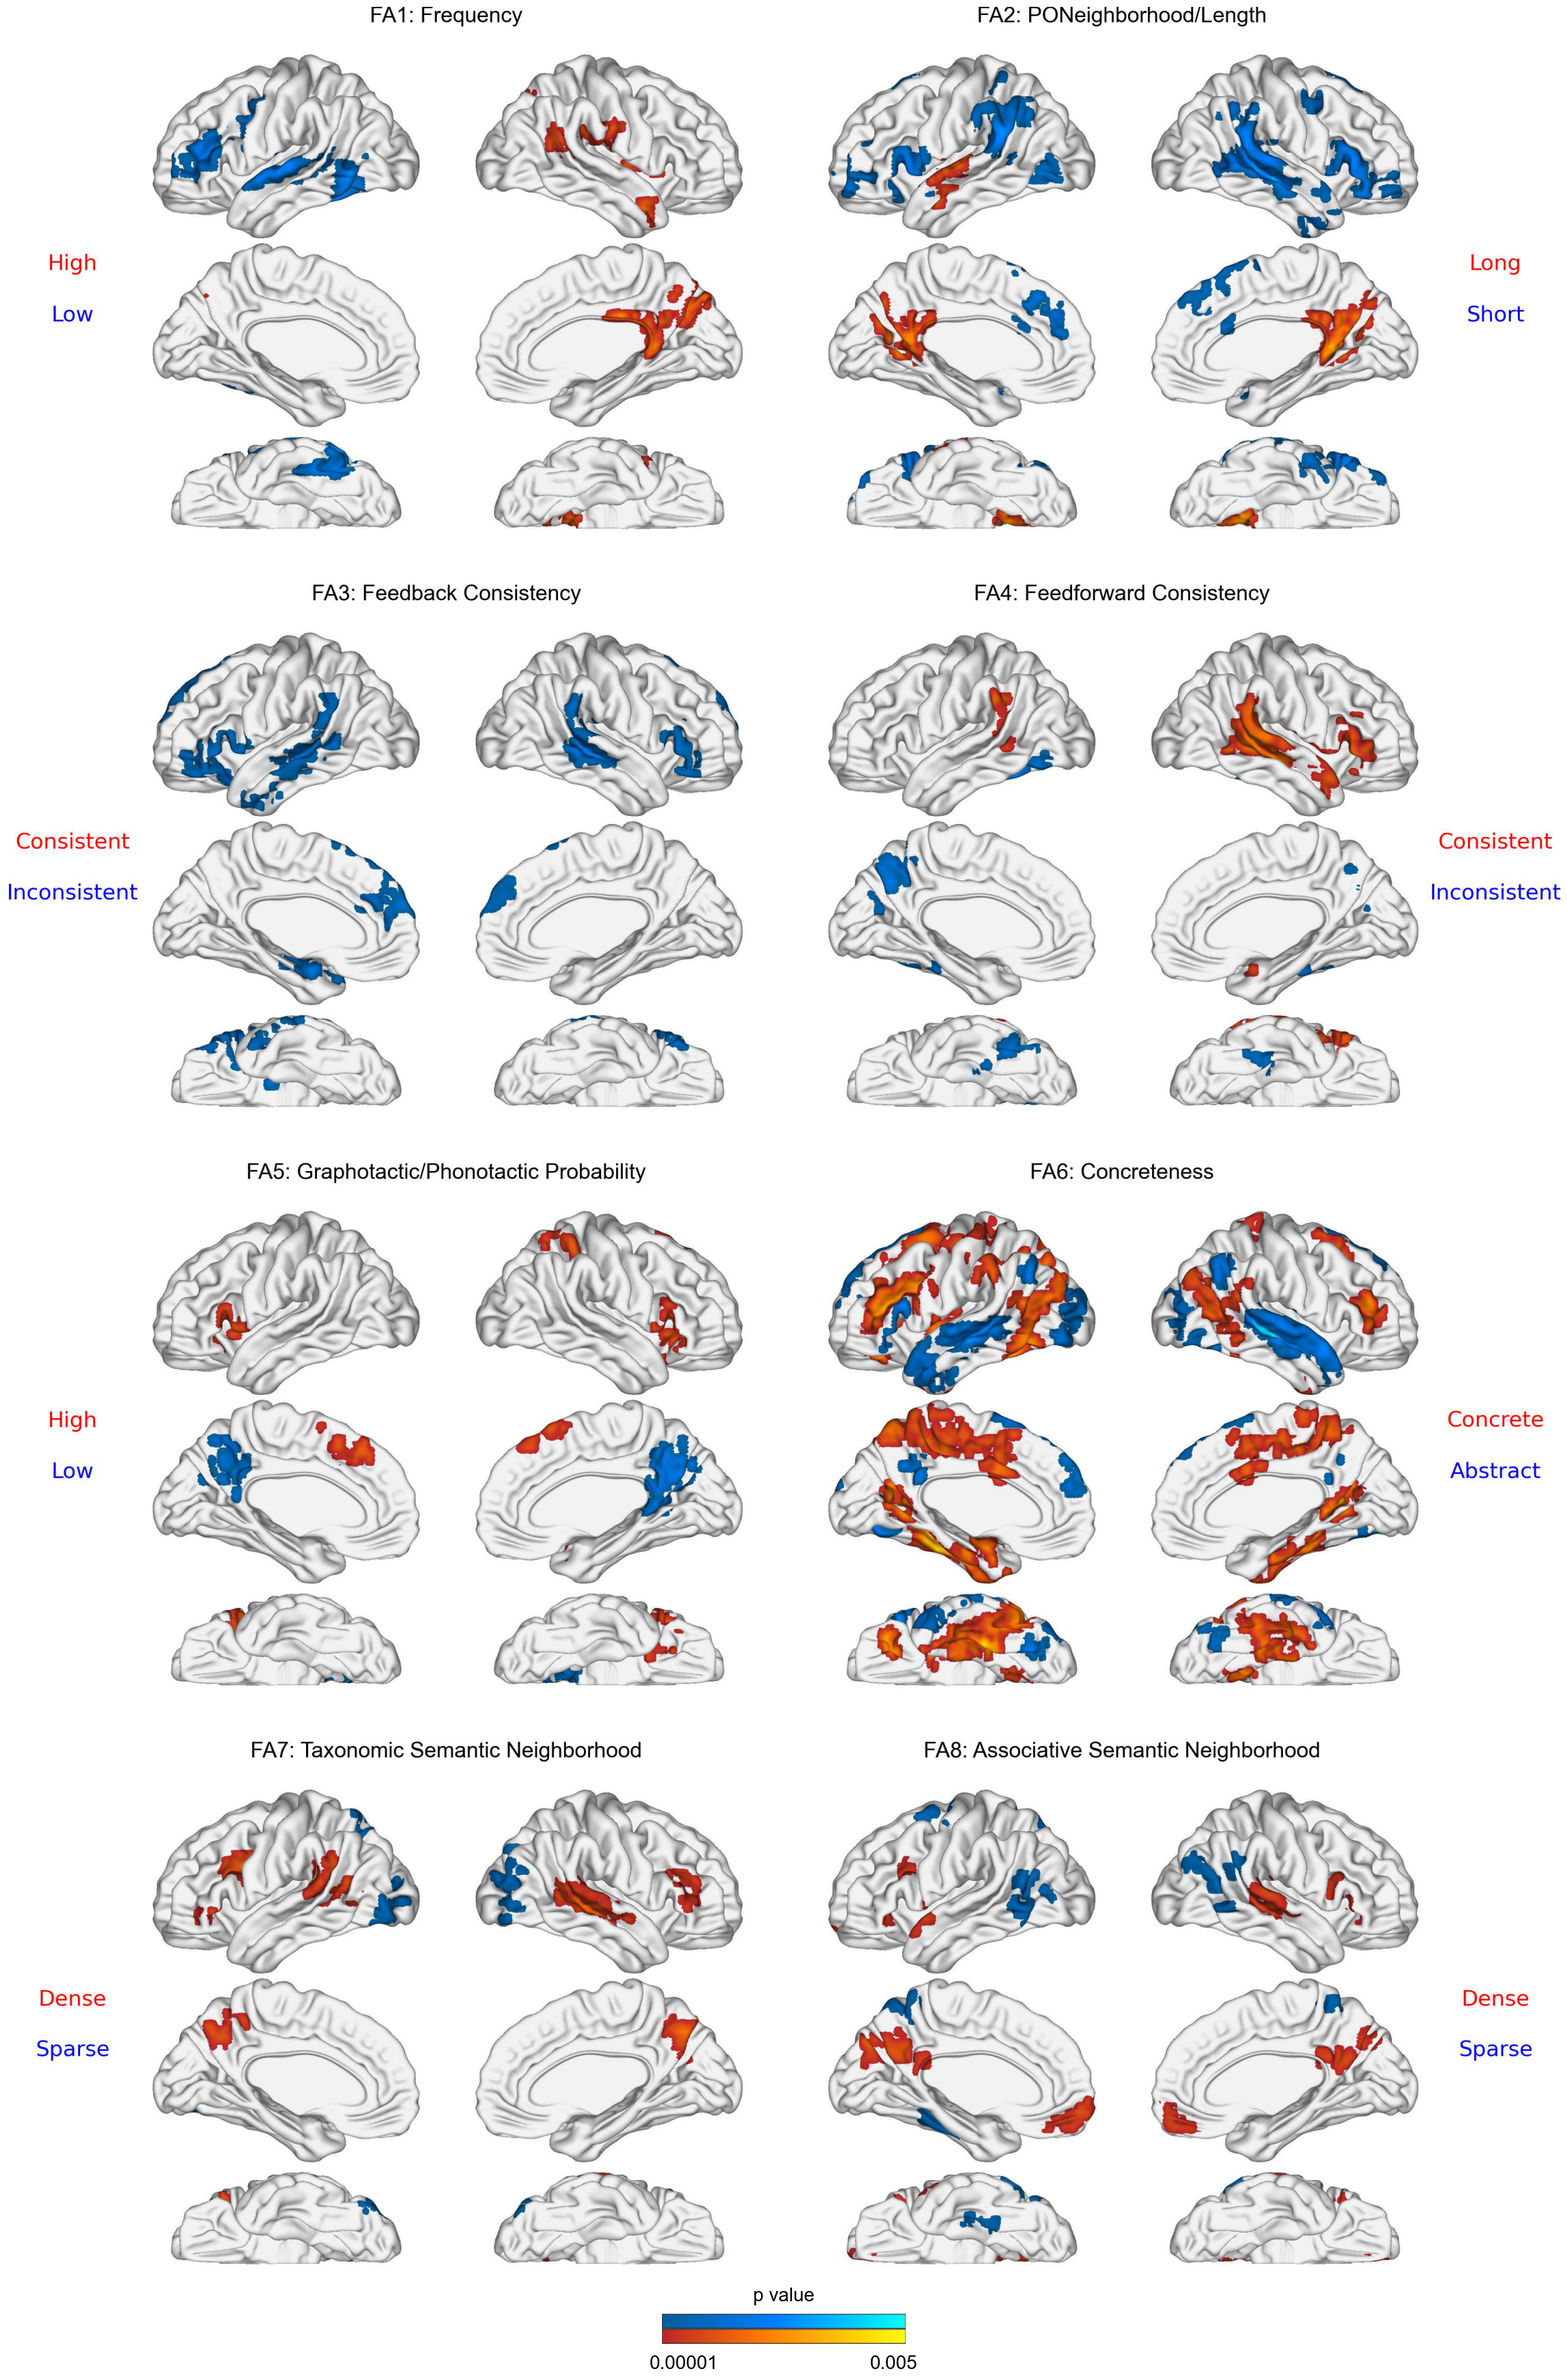

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec

# Load the images
image_path1 = os.path.join(Dir_figure,'figure_8in1_layout4.jpg')
image_path2 = os.path.join(Dir_figure,'colorbar_layout1.png')
img1 = mpimg.imread(image_path1)
img2 = mpimg.imread(image_path2)

# Get the raw dimensions of the images
height1, width1, _ = img1.shape
height2, width2, _ = img2.shape

# Resize the second image to 60% of its original size
resize_factor = 0.3
new_height2 = int(height2 * resize_factor)
new_width2 = int(width2 * resize_factor)

total_height = height1 + new_height2
max_width = max(width1, new_width2)
fig = plt.figure(figsize=(max_width / 100, total_height / 100))  # Convert pixels to inches

# Define a GridSpec with two rows
gs = GridSpec(2, 1, height_ratios=[height1, new_height2], hspace=0.03)


ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(img1)
ax1.axis('off')  # Turn off axes for a clean look

ax2 = fig.add_subplot(gs[1, 0])

ax2.imshow(img2)
ax2.axis('off')
ax2.text(0.5, 1.6, 'p value', 
        transform=ax2.transAxes, 
        fontsize=20, color='black', 
        ha='center', va='center',fontproperties=prop)
# ax2.text(-0.05, -0.7, '0.005', 
#         transform=ax2.transAxes, 
#         fontsize=20, color='black', 
#         ha='left', va='center',fontproperties=prop)
# ax2.text(1.05, -0.7, '0.00001', 
#         transform=ax2.transAxes, 
#         fontsize=20, color='black', 
#         ha='right', va='center',fontproperties=prop)

ax2.text(-0.05, -0.7, '0.00001', 
        transform=ax2.transAxes, 
        fontsize=20, color='black', 
        ha='left', va='center',fontproperties=prop)
ax2.text(1.05, -0.7, '0.005', 
        transform=ax2.transAxes, 
        fontsize=20, color='black', 
        ha='right', va='center',fontproperties=prop)

filename = os.path.join(Dir_figure,'figure_8in1_layout5.jpg')
plt.savefig(filename, bbox_inches='tight', pad_inches=0,dpi=600)
plt.show()


In [7]:
Dir_figure

'/work/desai-lab/xuanyang/Project/Semantic/analysis/ParametricModulation/Nastase/allstories/FactorAnalysis/models/Nvar113NFA8_LPAC_multipleReg/figures_SVC/threshold_SVC3_LR/bisidedNN2_1tailp005/palette2'